In [3]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [4]:
from omfit_classes import omfit_eqdsk

In [5]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

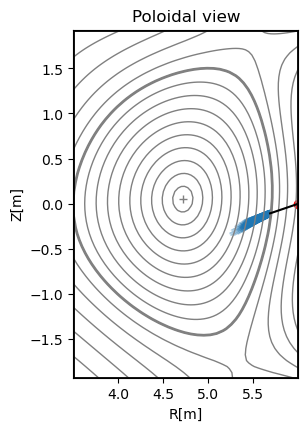

In [67]:
#Python
# originally by Orso
# modified by Zhixuan 1/7/2015

tfile = '/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/test_toray/SCAN/work/fastran_ec_toray_5/toray.nc'
gfile = '/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/test_toray/SCAN/work/fastran_tr_fastran_7/g000001.00001'

data = Dataset(tfile)
geqdsk = omfit_eqdsk.OMFITgeqdsk(gfile)

alpha = 0.5

# get/calculate physical quantites for rays
wr = data['wr'][:,:]#[::np.downsamp, ::np.downsamp]
mask = np.ones(wr.shape)
mask[np.where(wr == 0)] = np.nan
mask = mask.T

wphi = data['wphi'][:,:].T * mask
wr = wr.T * mask / 100.0
wx = wr * np.cos(wphi + phi_exp)
wy = wr * np.sin(wphi + phi_exp)

wz = data['wz'][:,:].T * mask / 100.0

x0t = data['x0'][0] / 100.0
y0t = data['y0'][0] / 100.0
R0t = np.sqrt(x0t**2 + y0t**2)
phi0t = np.arctan2(y0t, x0t)
x0 = R0t * np.cos(phi0t + phi_exp)
y0 = R0t * np.sin(phi0t + phi_exp)

z0 = data['z0'][0] / 100.0
x1 = wr[0, 0] * np.cos(wphi[0, 0] + phi_exp)
y1 = wr[0, 0] * np.sin(wphi[0, 0] + phi_exp)

z1 = data['wz'][:,:].T[0, 0] / 100.0

s = data['delpwr'][:,:].T
s = s / s[0]

# poloidal cross-section
plt.subplot(1, 2, 2)  # ,aspect='equal')

Zmax = max(geqdsk['ZLIM'])
Zmin = min(geqdsk['ZLIM'])
geqdsk.plot(only2D=True, color='grey') #POLOIDAL CROSS SECTION

# calculate the resonance field
B_res = data['freqcy'][:] / 2.802e10


# accurate resonant surface
R, Z = np.meshgrid(geqdsk['AuxQuantities']['R'], geqdsk['AuxQuantities']['Z'])
B = np.sqrt(geqdsk['AuxQuantities']['Bt'] ** 2 + geqdsk['AuxQuantities']['Br'] ** 2 + geqdsk['AuxQuantities']['Bz'] ** 2)
#plt.contour(R, Z, B, [B_res], colors='r') #POLODIAL RESONANT SURFACE

# approximate resonant surface, as the one shown in the toroidal view
t_angle = np.arange(0, 2 * np.pi, 0.02 * np.pi)
t_angle = np.append(t_angle, 2 * np.pi)
R_res = abs(geqdsk['RCENTR'] * geqdsk['BCENTR'] / B_res)
X_res = R_res * np.cos(t_angle)
Y_res = R_res * np.sin(t_angle)
#plt.plot([R_res, R_res], [Zmin, Zmax], 'r--') #POLODIAL APPROXIMATE RESONANT SURFACE?



plt.scatter(wr, wz, s, alpha=alpha)#, cmap='rainbow') ## POLOIDAL RAYS ##this used plotc, which colors the scatter points with a colorbar

plt.plot([R0t, wr[0, 0]], [z0, z1], 'k') ##POLOIDAL ANTENNA
plt.xlabel('R[m]')
plt.ylabel('Z[m]')

plt.title('Poloidal view')

plt.scatter(6,0,color='r')